In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os
from statistics import mean
from statsmodels.stats import multitest
import seaborn as sns

#USEFULL LISTS

filelist = ['psapsgpl1-analysis.csv',
            'psapsgpl3 kid tes spl si uncvsir3 hrt lun-analysis.csv',
            'psapvsir2-analysis.csv',
            'slccdh2-analysis.csv',
            'slcvsir1-analysis.csv',
            'slcvsir3 unccdh3 kid tes-analysis.csv',
            'unccdh1-analysis.csv',
            'uncsgpl2-analysis.csv']
organs = {'bd':"Bladder",
          'cb':"Cerebellum",
          'hrt':"Heart",
          'kid':"Kidney",
          'liv':"Liver",
          'lun':"Lung",
          'ntc':"NTC",
          'ob':"Olfactory Bulb",
          'si':"Small Intestine",
          'spl':"Spleen",
          'tes':"Testis"}
genes = {'cdh':"Cdh23",
         'psap':"Psap",
         'sgpl':"Sgpl1",
         'slc':"Slc29a3",
         'unc':"Unc5b",
         'vsir':"Vsir"}

In [2]:
#CREATES GENE ORGAN MOUSE ALLELE COLUNS
#STACK LINKED ALLELE INFO IN ONE ROW
def parse(file, ctrl_samplenames = 'epb', exp_samplenames = 'unc'):

    #OPEN FILE AND CREATE EMPTY COLS
    data = pd.read_csv(file).reset_index()
    data.columns = ["Index"] + list(data.loc[0][1:])
    data=data.drop(index = 0)
    [data["Gene"], data["Allele"], data["Organ"], data["Mouse"]] = ["","","",""]
    
    #FILL COLS ROW BY ROW
    for i,row in data.iterrows():
        row["Gene"] = row["Target"].split(" ")[0]
        row["Allele"] = row["Target"].split(" ")[1]
        if row["Sample/NTC/Control"] == "ntc":
            row["Organ"] = "ntc"
            row["Mouse"] = "ntc"
        else:
            row["Organ"] = row["Sample/NTC/Control"].split(" ")[0]
            row["Mouse"] = row["Sample/NTC/Control"].split(" ")[1]
    data = data.reset_index().drop(columns = ["index","Threshold"]).sort_values(by=['Allele'])
    
    # stack allele in one row via creating new DF
    
    dotan = pd.DataFrame(columns = ['Gene','Organ','Mouse','Well','WTQ','SNPQ','WTCI','SNPCI'])
    genelist = set(data["Gene"])
    for i in genelist:
        a1 = data.loc[data['Gene']==i]
        orglist = set(a1["Organ"])
        for j in orglist:
            b1=a1.loc[a1['Organ']==j]
            muslist = set(b1["Mouse"])
            for m in muslist:
                c1=b1.loc[b1["Mouse"]==m]
                wellist = set(c1["Index"])
                for w in wellist:
                    d1=c1.loc[c1["Index"]==w]
                    snpq = list(d1["Concentration (copies/µL)"])[0]
                    wtq = list(d1["Concentration (copies/µL)"])[1]
                    snpci = list(d1["CI (95%)"])[0]
                    wtci = list(d1["CI (95%)"])[1]
                    dotan = dotan.append(pd.Series({
                    'Gene':i,
                    'Organ':j,
                    'Mouse':m,
                    'Well':w,
                    'WTQ':wtq,
                    'SNPQ':snpq,
                    'WTCI':wtci,
                    'SNPCI':snpci}), ignore_index=True)
                                         
    # calculating relative expression RE and sum of relative errors
    
    [dotan["RE"], dotan["CISUM"], dotan["Group"]] = ['','','']
    for i,row in dotan.iterrows():
        row["WTCI"] = row["WTCI"].replace("%","")
        row["SNPCI"] = row["SNPCI"].replace("%","")
        if ctrl_samplenames in row["Mouse"]:
            row["Group"] = "ctr"
        if exp_samplenames in row["Mouse"]:
            row["Group"] = "exp"
        if 'ntc' in row["Mouse"]:
            row["Group"] = "ntc"    
        if float(row["WTQ"]) == 0:
            row["RE"] = ""
            row["CISUM"] = ""
        elif float(row["SNPQ"]) == 0:
            row["RE"] = ""
            row["CISUM"] = ""
        else:
            row["RE"] = float(row["WTQ"])/float(row["SNPQ"])
            row["CISUM"] = float(row["WTCI"]) + float(row["SNPCI"])
    dotan['CISUM']=pd.to_numeric(dotan['CISUM'])
    dotan['RE']=pd.to_numeric(dotan['RE'])
    return(dotan)


In [3]:
def bigdfcreator(filelist, ntc = "ntc"):
    bigdf = pd.DataFrame()
    for dfdf in filelist:
        data = pd.read_csv(dfdf)
        for o in set(data["Organ"]):
            if o != ntc:
                a1 = data[data.Organ == o]
                for g in set(a1["Gene"]):
                    if g != ntc:
                        a2 = a1[a1.Gene == g]
                        a2["WTQ"] = pd.to_numeric(a2["WTQ"])
                        a2["SNPQ"] = pd.to_numeric(a2["SNPQ"])
                        a2=a2.groupby(["Mouse"]).mean()
                        for i in set(a2.index):
                            bigdf.loc[i,f"{o}{g} wt {dfdf}"] = a2.loc[i,"WTQ"]
                            bigdf.loc[i,f"{o}{g} snp {dfdf}"] = a2.loc[i,"SNPQ"]

    return(bigdf) 

In [4]:
def bigdfreg(i,j,bigdf):
    ax=sns.regplot(x =i, y = j, data=bigdf)
    ax=sns.scatterplot(x =i, y = j, hue=bigdf.index, data=bigdf, s=200)
    x=bigdf[i]
    y=bigdf[j]
    if np.all(x.values != y.values):
        x=pd.concat([x, y], axis=1).dropna()[i]
        y=pd.concat([x, y], axis=1).dropna()[j]
        corr='R = ' + str(stats.pearsonr(x, y)[0])+ ' p = '+ str(stats.pearsonr(x, y)[1])
    else:
        corr = "R=1"
        ax.set_title(corr, fontstyle = 'oblique', fontsize=20)
        plt.show()
        fig = ax.get_figure()
        fig.savefig(f"roflan/{i,j}correlpic.jpg", bbox_inches="tight", dpi = 100)
    return(fig, stats.pearsonr(x, y))

In [5]:
def graph1(file, organ, gene, ax, delete_outliers = True, ztresh = 2, trait = "RE", errors = "CISUM", title = "GRAPH", y = 'y'):
    
    #plt.style.use('fivethirtyeight')
    #plt.style.use('seaborn-whitegrid')
    csfont = {'fontname':'Arial', 'fontsize':14}
    plt.rcParams['axes.facecolor'] = 'white'
    plt.figure(figsize = [10, 10])
    
    s = 60
    edgecolors='#000000'
    alpha = 0.7
    ex_c = 'red'
    ct_c = 'blue'
    
    
    # divide data to mouse groups, cut organ/gene info, take means
    ct = file[file.Group == 'ctr']  
    ex = file[file.Group == 'exp']
    ct = ct[ct.Organ == organ]
    ex = ex[ex.Organ == organ]
    ct = ct[ct.Gene == gene]
    ex = ex[ex.Gene == gene]
    ct = ct.groupby("Mouse").mean().reset_index()
    ex = ex.groupby("Mouse").mean().reset_index()

    #create two bars with sem 
        
    ax.bar(0.1, ct[trait].mean(), color = 'white', edgecolor='black',width=0.5, alpha = 1, zorder=-1)
    ax.errorbar(0.1, ct[trait].mean(), (ct[trait].sem()), c = '#000000', capsize=9)

    #plt.errorbar(0.1, ct[trait].mean(), xerr = 0.1, c = '#000000')
    
    ax.bar(0.8, ex[trait].mean(), color = 'white', edgecolor='black',width=0.5, alpha = 1, zorder=-1)
    ax.errorbar(0.8, ex[trait].mean(), (ex[trait].sem()), c = '#000000', capsize=9)
    #plt.errorbar(0.8, ex[trait].mean(), xerr = 0.1, c = '#000000')
        

        

    #create two csatters and two lists for stats
    ctrlist1 = []
    explist1 = []
    ctrlcoords = []
    expcoords = []
    
    for i in (list(ct['Mouse'])):
        x =(-0.15+(0.45/len(list(ct['Mouse'])))*(list(ct['Mouse']).index(i) + 1))
        y =(ct.loc[ct['Mouse']==i][trait])
        if pd.isna(float(y)) == False:
            ctrlist1.append(float(y))
            ctrlcoords.append(x)
            ax.scatter(x, y,s=s,edgecolors=edgecolors, c = ct_c, alpha = 0.7)    
            ax.errorbar(x, y, xerr=0, yerr= y*(ct.loc[ct['Mouse']==i][errors])/400,c = ct_c, alpha = 0.7) # 38% CI
            ax.annotate(i,(x+0.01,y+0.01))
    
    for i in (list(ex['Mouse'])):
        x =(0.55+(0.45/len(list(ex['Mouse'])))*(list(ex['Mouse']).index(i) + 1))
        y =(ex.loc[ex['Mouse']==i][trait])
        if pd.isna(float(y)) == False:
            explist1.append(float(y))
            expcoords.append(x)
            ax.scatter(x, y,s=s,edgecolors=edgecolors, c = ex_c, alpha = 0.7)    
            ax.errorbar(x, y, xerr=0, yerr= y*(ex.loc[ex['Mouse']==i][errors])/400,c = ex_c, alpha = 0.7) 
            ax.annotate(i,(x+0.01,y+0.01))
    #print(explist1, ctrlist1)
    
    
        #delete outliars module     
    ctrlist =[]
    explist =[]
    if delete_outliers == True:
        zscc1 = list(stats.zscore(ctrlist1))
        #print(zscc1)
        for i in zscc1:
            #print(i)
            #print(list(zscc1).index(i))
            if abs(i) < ztresh:
                ctrlist.append(ctrlist1[list(zscc1).index(i)])
            else:
                ax.scatter(ctrlcoords[zscc1.index(i)], ctrlist1[zscc1.index(i)], s=300, marker="x", c="k")
         
        zsce1 = list(stats.zscore(explist1))
        #print(zsce1) 
        for i in zsce1:
            #print(i)
            #print(list(zsce1).index(i))
            if abs(i) < ztresh:
                explist.append(explist1[list(zsce1).index(i)])
            else:
                ax.scatter(expcoords[zsce1.index(i)], explist1[zsce1.index(i)], s=300, marker="x", c="k")      
    else:
        ctrlist = ctrlist1
        explist = explist1    
    
    if len(explist) < 3 or len(ctrlist) < 3:
        return(print('this is ploho'))
    shctr = str(round(stats.shapiro(ctrlist)[0],5))
    shexp = str(round(stats.shapiro(explist)[0],5))
    ttest = str(round(stats.ttest_ind(ctrlist, explist)[1],5))
    utest = str(round(stats.mannwhitneyu(ctrlist, explist)[1],5))

    
    if float(ttest) < 0.05 or float(utest) <0.05:    
        c="r"
        fs = 10
    else:
        c="k"
        fs=10
    
    #ax.set_yticks(**csfont)
    ax.set_ylabel("Relative expression")
    ax.set_title(title)    
    
    ax.set_xticks([0.1,0.35,0.8])
    ax.set_xticklabels([f"control \n shapiro = {shctr}",
                                f"u = {utest} \n t = {ttest}",
                                f"experiment \n shapiro = {shexp}"], color=c, fontsize=fs)
    ax.set_title(organ + " " + gene)
    
    
    #plt.text(0.75,-0.4, s=)
    #plt.text(0,-1, s="shapiro = "+shctr)
    #plt.text(0.7,-1, s="shapiro = "+shexp)
    #plt.text(0.4,-1, s="u = "+ utest + "\n" "t = "+ ttest)
    

    #plt.xticks(d, ('Контроль Slc29a3', 'UNCdM1R1 Slc29a3', 'Контроль Unc5b','UNCdM1R1 Unc5b'),**csfont, rotation=70)


    #plt.savefig(f"pics/{organ} bl {gene} bl {title}.jpg", transparent=True, bbox_inches="tight", dpi = 200)
    
    
    #plt.show()
    return(ax)

In [6]:
def graph2(file, organ, gene, ax, wt = "WTQ", snp = "SNPQ", erwt = "WTCI", ersnp = "SNPCI", title= "s", y = 'y'):
    
    #plt.style.use('fivethirtyeight')
    #plt.style.use('seaborn-whitegrid')
    csfont = {'fontname':'Arial', 'fontsize':14}
    plt.rcParams['axes.facecolor'] = 'white'
    plt.figure(figsize = [10, 10])
    
    s = 60
    edgecolors='#000000'
    alpha = 0.7
    ex_c = 'red'
    ct_c = 'blue'
    
    
    # divide data to mouse groups, cut organ/gene info, take means
    file = file[file.Organ == organ]
    file = file[file.Gene == gene]

    file[erwt] = [i.strip('%') for i in file[erwt]]
    file[erwt] = file[erwt].replace("-",np.nan)
    file[ersnp] = [i.strip('%') for i in file[ersnp]]
    file[ersnp] = file[ersnp].replace("-",np.nan)
    #print(file)
    file[erwt]=pd.to_numeric(file[erwt])
    file[ersnp]=pd.to_numeric(file[ersnp])
    file[wt]=pd.to_numeric(file[wt])
    file[snp]=pd.to_numeric(file[snp])
    file = file.groupby("Mouse").mean().reset_index()    
    
    
    for i in list(file["Mouse"]):
        x=list(file["Mouse"]).index(i)
        y=file.loc[file['Mouse']==i]
        #print(y)
        ax.bar(x, y[wt], yerr = [[0] , [float(y[wt]*y[erwt]/100)]], color = 'b', edgecolor='black',width=0.3, alpha = 1, zorder=-1)
        #plt.errorbar(list(file["Mouse"]).index(i), file.loc[file['Mouse']==i][wt], yerr = [[0] , [float(y[wt]*y[erwt]/100)]], c = '#000000', capsize=9)
        ax.bar(x+0.3, y[snp], yerr = [[0] , [float(y[snp]*y[ersnp]/100)]], color = 'g', edgecolor='black',width=0.3, alpha = 1, zorder=-1)
        #plt.errorbar(list(file["Mouse"]).index(i)+0.3, file.loc[file['Mouse']==i][snp], yerr = [0,file.loc[file['Mouse']==i][snp]*file[ersnp].mean()/100], c = '#000000', capsize=9)
    ax.text(-1,-1, s="blue is black")
    ax.set_xticks(list(range(len(list(file["Mouse"])))))
    ax.set_xticklabels(list(file["Mouse"]))
    ax.set_ylabel("transcript conc")
    ax.set_title(organ + " " + gene)
    #plt.savefig(f"pics2/{organ} bl {gene} bl {title}.jpg", transparent=True, bbox_inches="tight", dpi = 200)
    #plt.show()
    return(ax)

In [7]:
def graph3(file, organ, gene, ax, delete_outliers = True, ztresh = 2, trait = "RE", errors = "CISUM", title = "GRAPH", y = 'y'):
    
    #plt.style.use('fivethirtyeight')
    #plt.style.use('seaborn-whitegrid')
    csfont = {'fontname':'Arial', 'fontsize':14}
    plt.rcParams['axes.facecolor'] = 'white'
    plt.figure(figsize = [10, 10])
    
    s = 60
    edgecolors='#000000'
    alpha = 0.7
    ex_c = 'red'
    ct_c = 'blue'
    
    
    # divide data to mouse groups, cut organ/gene info, take means
    ct = file[file.Group == 'ctr']  
    ex = file[file.Group == 'exp']
    ct = ct[ct.Organ == organ]
    ex = ex[ex.Organ == organ]
    ct = ct[ct.Gene == gene]
    ex = ex[ex.Gene == gene]
    #ct = ct.groupby("Mouse").mean().reset_index()
    #ex = ex.groupby("Mouse").mean().reset_index()

    #create two bars with sem 
        
    ax.bar(0.1, ct[trait].mean(), color = 'white', edgecolor='black',width=0.5, alpha = 1, zorder=-1)
    ax.errorbar(0.1, ct[trait].mean(), (ct[trait].sem()), c = '#000000', capsize=9)

    #plt.errorbar(0.1, ct[trait].mean(), xerr = 0.1, c = '#000000')
    
    ax.bar(0.8, ex[trait].mean(), color = 'white', edgecolor='black',width=0.5, alpha = 1, zorder=-1)
    ax.errorbar(0.8, ex[trait].mean(), (ex[trait].sem()), c = '#000000', capsize=9)
    #plt.errorbar(0.8, ex[trait].mean(), xerr = 0.1, c = '#000000')
        

        

    #create two csatters and two lists for stats
    ctrlist1 = []
    explist1 = []
    ctrlcoords = []
    expcoords = []
    
    for i in list(set(ct['Mouse'])):
        #print(sorted(list(set(ct['Mouse']))))
        x =-0.15+(0.45/len(list(set(ct['Mouse']))))*(sorted(list(set(ct['Mouse']))).index(i) + 1)
        y =(ct.loc[ct['Mouse']==i][trait])
        dob = -0.005
        for j in list(y):
            if pd.isna(float(j)) == False:
                ctrlist1.append(float(j))
                x2=x+dob
                ctrlcoords.append(x2)
                ax.scatter(x2, (float(j)),s=s,edgecolors=edgecolors, c = ct_c, alpha = 0.7)    
                ax.errorbar(x2, (float(j)), xerr=0, yerr= (float(j))*(ct.loc[ct['RE']==j][errors])/100,c = ct_c, alpha = 0.7) # 38% CI
                ax.annotate(i,(x2+0.01,float(j)+0.01))
                dob+=0.01
                
    for i in list(set(ex['Mouse'])):
        x =0.55+(0.45/len(list(set(ex['Mouse']))))*(sorted(list(set(ex['Mouse']))).index(i) + 1)
        y =(ex.loc[ex['Mouse']==i][trait])
        dob = -0.005
        for j in list(y):
            if pd.isna(float(j)) == False:
                explist1.append(float(j))
                x2=x+dob
                expcoords.append(x2)
                ax.scatter(x2, (float(j)),s=s,edgecolors=edgecolors, c = ex_c, alpha = 0.7)    
                ax.errorbar(x2, (float(j)), xerr=0, yerr= (float(j))*(ex.loc[ex['RE']==j][errors])/100,c = ex_c, alpha = 0.7) # 38% CI
                ax.annotate(i,(x2+0.01,float(j)+0.01))
                dob+=0.01
                
                
        #delete outliars module     
    ctrlist =[]
    explist =[]
    if delete_outliers == True:
        zscc1 = list(stats.zscore(ctrlist1))
        #print(zscc1)
        for i in zscc1:
            #print(i)
            #print(list(zscc1).index(i))
            if abs(i) < ztresh:
                ctrlist.append(ctrlist1[list(zscc1).index(i)])
            else:
                ax.scatter(ctrlcoords[zscc1.index(i)], ctrlist1[zscc1.index(i)], s=300, marker="x", c="k")
         
        zsce1 = list(stats.zscore(explist1))
        #print(zsce1) 
        for i in zsce1:
            #print(i)
            #print(list(zsce1).index(i))
            if abs(i) < ztresh:
                explist.append(explist1[list(zsce1).index(i)])
            else:
                ax.scatter(expcoords[zsce1.index(i)], explist1[zsce1.index(i)], s=300, marker="x", c="k")      
    else:
        ctrlist = ctrlist1
        explist = explist1

        
        
    if len(explist) < 3 or len(ctrlist) < 3:
        return(print('this is ploho'))
    shctr = str(round(stats.shapiro(ctrlist)[0],5))
    shexp = str(round(stats.shapiro(explist)[0],5))
    ttest = str(round(stats.ttest_ind(ctrlist, explist)[1],5))
    utest = str(round(stats.mannwhitneyu(ctrlist, explist)[1],5))
    
    
    
    if float(ttest) < 0.05 or float(utest) <0.05:    
        c="r"
        fs = 11
    else:
        c="k"
        fs=10
    
    #ax.set_yticks(**csfont)
    ax.set_ylabel("Relative expression")
    ax.set_title(title)    
    
    ax.set_xticks([0.1,0.35,0.8])
    ax.set_xticklabels([f"control \n shapiro = {shctr}",
                                f"u = {utest} \n t = {ttest}",
                                f"experiment \n shapiro = {shexp}"], color=c, fontsize=fs)
    ax.set_title(organ + " " + gene)
    #plt.text(0,-1, s="shapiro = "+shctr)
    #plt.text(0.7,-1, s="shapiro = "+shexp)
    #plt.text(0.4,-1, s="u = "+ utest + "\n" "t = "+ ttest)
    

    #plt.xticks(d, ('Контроль Slc29a3', 'UNCdM1R1 Slc29a3', 'Контроль Unc5b','UNCdM1R1 Unc5b'),**csfont, rotation=70)


    #plt.savefig(f"pics/{organ} bl {gene} bl {title}.jpg", transparent=True, bbox_inches="tight", dpi = 200)
    
    
    #plt.show()
    return(ax)

In [8]:
def FDR(filelist, delete_outliers = True, ztresh = 2, ntc="ntc",groupbymouse = True, fdralp=0.05):
    bigdf=pd.DataFrame()
    bigdf=pd.DataFrame(columns = ["File", "Organ", "Gene", "shexp","shctr","t-test", "u-test"])
    for dfdf in filelist:
        #print(dfdf)
        data=parse(dfdf)
        #data = pd.read_csv(dfdf)
        for o in set(data["Organ"]):
            if o != ntc:
                a1 = data[data.Organ == o]
                for g in set(a1["Gene"]):
                    if g != ntc:
                        a2 = a1[a1.Gene == g]
                        a2["WTQ"] = pd.to_numeric(a2["WTQ"])
                        a2["SNPQ"] = pd.to_numeric(a2["SNPQ"])
                        if groupbymouse == True:
                            a2=a2.groupby(["Mouse"]).mean().reset_index()

                        act = list(a2.loc[a2.Mouse.str.contains("epb")]["RE"].dropna())
                        aex = list(a2.loc[a2.Mouse.str.contains("unc")]["RE"].dropna())


                                #delete outliars module     
                        if delete_outliers == True:
                            ctrlist1 = []
                            zscc1 = list(stats.zscore(act))
                            #print(zscc1)
                            for i in zscc1:
                                #print(i)
                                #print(list(zscc1).index(i))
                                if abs(i) < ztresh:
                                    ctrlist1.append(act[list(zscc1).index(i)])
                            explist1 =[]
                            zsce1 = list(stats.zscore(aex))
                            #print(zsce1) 
                            for i in zsce1:
                                #print(i)
                                #print(list(zsce1).index(i))
                                if abs(i) < ztresh:
                                    explist1.append(aex[list(zsce1).index(i)])      
                            act = ctrlist1
                            aex = explist1



                        #print(o,g,act,"\n",aex)
                        if len(act) < 3 or len(aex) < 3:
                            print('this is ploho')
                        else:
                            shctr = str(round(stats.shapiro(act)[0],5))
                            shexp = str(round(stats.shapiro(aex)[0],5))
                            ttest = str(round(stats.ttest_ind(act, aex)[1],5))
                            utest = str(round(stats.mannwhitneyu(act, aex)[1],5))

                            bigdf = bigdf.append(pd.Series({"File":dfdf, "Organ":o, "Gene":g,"shexp":shexp,"shctr":shctr, "t-test":ttest, "u-test":utest}), ignore_index=True)
    bigdf["u-test"] = pd.to_numeric(bigdf["u-test"])
    bigdf["t-test"] = pd.to_numeric(bigdf["t-test"])
    bigdf["ufdr"] = multitest.fdrcorrection(bigdf["u-test"].values, alpha=fdralp, method='indep', is_sorted=False)[0]
    bigdf["tfdr"] = multitest.fdrcorrection(bigdf["t-test"].values, alpha=fdralp, method='indep', is_sorted=False)[0]
    return(bigdf)

#fdrdf = FDR(filelist)

In [9]:
def norm(file):
    for o in set(file["Organ"]):
        #print(o)
        if o != 'ntc':
            a1 = file[file.Organ == o]
            for g in set(a1["Gene"]):
                #print(g)
                if g != 'ntc':
                        ct = file[file.Group == "ctr"]
                        ct = ct[ct.Gene == g]
                        mean=ct['RE'].mean()
                        print(mean)
                        for group in ["ctr", "exp"]:
                            print(o, g, group)
                            ct = file[file.Group == group]
                            ct = ct[ct.Gene == g]
                            for i,row in file.iterrows():
                                if row['Organ'] == o and row["Gene"] == g:
                                    re=float(row['RE'])
                                    #print('...')
                                    #print(re)
                                    #print(mean)
                                    #print(re/mean)
                                    file.loc[i,'RE'] = re/mean
    return(file)

In [10]:
for ztresh in [1, 2, 3]:
    for groupbymouse in [False]:
        for fdralp in [1]:
            fdrdf = FDR(filelist, ztresh = ztresh,groupbymouse = groupbymouse, fdralp=fdralp)
            #tru = fdrdf[fdrdf.ufdr == True]
            tru = fdrdf
            dr = f"wells_pics ztresh= {ztresh}, groupbymouse ={groupbymouse}, fdralp = {fdralp} ALL"
            os.makedirs(dr, exist_ok=True)
            #print(tru)
            for i,row in tru.iterrows():
                f=row["File"]
                file = norm(parse(f))
                organ = row["Organ"]
                gene = row["Gene"]
                fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize = (30,9.5))
                graph1(file, organ, gene, ax1, delete_outliers = True, ztresh = ztresh, trait = "RE", errors = "CISUM", title = "GRAPH", y = 'y')             
                graph2(file, organ, gene, ax2, wt = "WTQ", snp = "SNPQ", erwt = "WTCI", ersnp = "SNPCI", title= "s", y = 'y')
                graph3(file, organ, gene, ax3, delete_outliers = True, ztresh = ztresh, trait = "RE", errors = "CISUM", title = "GRAPH", y = 'y')
                fig.savefig(f"{dr}/organ= {organ} gene= {gene} file= {f}.jpg", bbox_inches="tight", dpi = 100)


AttributeError: 'DataFrame' object has no attribute 'append'

In [17]:
#bdf1 = FDR(filelist, delete_outliers = True, ztresh = 3, ntc="ntc",groupbymouse = True, fdralp=0.1)
bdf1=0

In [11]:
def bigdfcreator(filelist, ntc = "ntc"):
    bigdf = pd.DataFrame()
    for dfdf in filelist:
        data = parse(dfdf)
        for o in set(data["Organ"]):
            if o != ntc:
                a1 = data[data.Organ == o]
                for g in set(a1["Gene"]):
                    if g != ntc:
                        a2 = a1[a1.Gene == g]
                        a2["WTQ"] = pd.to_numeric(a2["WTQ"])
                        a2["SNPQ"] = pd.to_numeric(a2["SNPQ"])
                        a2=a2.groupby(["Mouse"]).mean()
                        for i in set(a2.index):
                            bigdf.loc[i,f"{g} {o}_{dfdf} wt"] = a2.loc[i,"WTQ"]
                            bigdf.loc[i,f"{g} {o}_{dfdf} snp"] = a2.loc[i,"SNPQ"]

    return(bigdf) 

bdf2 = bigdfcreator(filelist, ntc = "ntc")
bdf2

AttributeError: 'DataFrame' object has no attribute 'append'

In [12]:
START!!!!


SyntaxError: invalid syntax (<ipython-input-12-c9fd599d118b>, line 1)

In [13]:
bdf2 = pd.read_excel('bdf2edited_onlygood.xlsx', index_col=0)
bdf2

,unc03,epb04,unc04,unc02,unc08,unc06,epb06,epb03,epb05,unc07,epb02,unc05,epb01,unc10,unc01,unc09
psap bd_psapsgpl1-analysis.csv wt,186.700,183.9500,143.35,169.85,174.0,241.95,102.70,171.8500,66.80,188.15,221.75,81.70,NaN,NaN,NaN,NaN
psap bd_psapsgpl1-analysis.csv snp,247.000,229.4500,177.35,200.95,193.3,272.50,111.80,194.6500,75.40,218.60,259.65,89.10,NaN,NaN,NaN,NaN
sgpl bd_psapsgpl1-analysis.csv wt,28.400,32.8500,24.40,32.15,25.2,53.05,9.80,29.8000,9.05,29.45,51.75,3.35,NaN,NaN,NaN,NaN
sgpl bd_psapsgpl1-analysis.csv snp,25.400,26.5000,19.15,25.05,16.2,34.50,7.20,19.4500,7.15,19.85,38.70,3.15,NaN,NaN,NaN,NaN
psap liv_psapsgpl1-analysis.csv wt,2504.850,4665.0000,2273.45,2363.75,NaN,3261.70,2562.45,2531.4000,3769.75,2528.85,3958.70,2688.00,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
unc si_uncsgpl2-analysis.csv snp,3.944,0.1885,6.30,0.00,NaN,1.70,0.00,1.5375,1.90,NaN,3.20,6.45,4.088,NaN,0.386,NaN
unc cb_uncsgpl2-analysis.csv wt,NaN,411.9500,380.40,579.60,NaN,416.05,497.05,411.4500,440.55,278.60,NaN,NaN,454.500,481.25,NaN,530.60
unc cb_uncsgpl2-analysis.csv snp,NaN,208.4000,269.00,423.30,NaN,309.45,373.05,280.0000,262.00,175.20,NaN,NaN,308.700,291.55,NaN,329.20
sgpl cb_uncsgpl2-analysis.csv wt,NaN,282.2000,244.10,374.45,NaN,277.55,349.50,273.8000,309.35,187.30,NaN,NaN,341.350,314.10,NaN,378.15


In [14]:
ls = []
for i in bdf2.transpose().columns:
    ls.append(' '.join(i.split(' ')[:-1]))
ls = set(ls)
ls

{'cdh bd_unccdh1-analysis.csv',
 'cdh cb_slccdh2-analysis.csv',
 'cdh hrt_slccdh2-analysis.csv',
 'cdh kid_slcvsir3 unccdh3 kid tes-analysis.csv',
 'cdh liv_unccdh1-analysis.csv',
 'cdh lun_slccdh2-analysis.csv',
 'cdh ob_unccdh1-analysis.csv',
 'cdh si_slccdh2-analysis.csv',
 'cdh spl_unccdh1-analysis.csv',
 'cdh tes_slcvsir3 unccdh3 kid tes-analysis.csv',
 'psap bd_psapsgpl1-analysis.csv',
 'psap cb_psapvsir2-analysis.csv',
 'psap hrt_psapvsir2-analysis.csv',
 'psap kid_psapsgpl3 kid tes spl si uncvsir3 hrt lun-analysis.csv',
 'psap liv_psapsgpl1-analysis.csv',
 'psap lun_psapvsir2-analysis.csv',
 'psap ob_psapsgpl1-analysis.csv',
 'psap si_psapsgpl3 kid tes spl si uncvsir3 hrt lun-analysis.csv',
 'psap si_psapvsir2-analysis.csv',
 'psap spl_psapsgpl3 kid tes spl si uncvsir3 hrt lun-analysis.csv',
 'psap tes_psapsgpl3 kid tes spl si uncvsir3 hrt lun-analysis.csv',
 'sgpl bd_psapsgpl1-analysis.csv',
 'sgpl cb_uncsgpl2-analysis.csv',
 'sgpl hrt_uncsgpl2-analysis.csv',
 'sgpl kid_psapsg

In [15]:
findf1 = pd.DataFrame()
for l in ls:
    wt=l+' wt'
    snp=l+' snp'
    f = bdf2.transpose().loc[:,[wt,snp]].replace(0.0, np.nan).dropna()
    
    wtl = []
    dell = []
    wtl1 = []
    dell1 = []
    
    
    for i,row in f.iterrows():
        if i.__contains__("epb"):
            wtl.append(row[wt]/row[snp])
        if i.__contains__("unc"):
            dell.append(row[wt]/row[snp])
            
            
    zscc1 = list(stats.zscore(wtl))
    for i in zscc1:
        if abs(i) < 2:
            wtl1.append(wtl[list(zscc1).index(i)])    
    zsce1 = list(stats.zscore(dell))
    for i in zsce1:
        if abs(i) < 2:
            dell1.append(dell[list(zsce1).index(i)])
    
    #{g} {o}_{dfdf} snp
    g = genes[l.split(' ')[0]]
    o = organs[l.split(' ')[1].split('_')[0]]
    f = l.split(' ')[1].split('_')[1]
    if dell1 and wtl1:
        findf1.loc[o,g] = mean(dell1)/mean(wtl1)
    else:
        print('abort',l,dell1,wtl1)
findf1

abort vsir si_psapvsir2-analysis.csv [] []
abort cdh liv_unccdh1-analysis.csv [] []
abort cdh si_slccdh2-analysis.csv [] []


,Psap,Cdh23,Unc5b,Vsir,Sgpl1,Slc29a3
Kidney,0.868216,2.083811,1.699580,0.878830,0.862228,0.667785
Spleen,1.183517,1.650809,1.100033,0.957361,0.942996,0.787658
Lung,0.946062,0.867167,1.962680,1.074320,0.997310,1.065635
Heart,0.812315,0.848983,0.571103,0.981206,1.062534,1.114812
Testis,0.952828,0.999723,0.979438,1.060970,1.001229,1.015187
Small Intestine,0.608483,NaN,0.526826,NaN,1.191531,1.393164
Cerebellum,0.979995,0.513418,0.943441,1.087644,1.021751,1.173842
Bladder,0.982680,0.503370,0.940212,1.136223,0.987902,0.992336
Olfactory Bulb,0.977260,1.083133,0.850323,0.904758,1.006112,0.980376
Liver,0.975276,NaN,1.124508,0.955425,0.959589,1.101853


<AxesSubplot:>

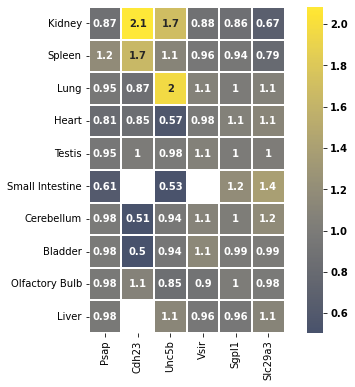

In [16]:
#
fig, ax = plt.subplots(figsize=(8,6))
ax.set_ylim([0,2])
plt.rcParams.update({'font.weight': 'bold'})
ax.set(yticks=[-0.5, 1.5], 
       xticks=[0, 1]) 
#       yticklabels='classes', 
#       xticklabels='classes')
#ax.yaxis.set_major_locator(ticker.IndexLocator(base=1, offset=0.5))
sns.heatmap(findf1, annot=True, square=True, cmap='cividis', center = 1,linewidths=1)
#fig.savefig("z=1.svg", bbox_inches="tight", dpi = 100)

In [17]:
print(genes, organs
     )

{'cdh': 'Cdh23', 'psap': 'Psap', 'sgpl': 'Sgpl1', 'slc': 'Slc29a3', 'unc': 'Unc5b', 'vsir': 'Vsir'} {'bd': 'Bladder', 'cb': 'Cerebellum', 'hrt': 'Heart', 'kid': 'Kidney', 'liv': 'Liver', 'lun': 'Lung', 'ntc': 'NTC', 'ob': 'Olfactory Bulb', 'si': 'Small Intestine', 'spl': 'Spleen', 'tes': 'Testis'}


In [24]:
picked = ['Cdh23 Cerebellum',
          'Slc29a3 Cerebellum',
          'Slc29a3 Kidney',
          'Slc29a3 Liver',
          'Vsir Bladder',
          'Vsir Cerebellum',
          'Vsir Olfactory Bulb']
picked

['Cdh23 Cerebellum',
 'Slc29a3 Cerebellum',
 'Slc29a3 Kidney',
 'Slc29a3 Liver',
 'Vsir Bladder',
 'Vsir Cerebellum',
 'Vsir Olfactory Bulb']

In [25]:
dfxyxpicked=dfxyx2.loc[dfxyx2.index.isin(picked)]
dfxyxpicked

,fc,top,TPM,TPMN
Vsir Bladder,1.13622,2.94393,23.9100,0.385956
Slc29a3 Liver,1.10185,-3.40039,0.9575,0.039703
Slc29a3 Kidney,0.667785,3.61391,18.9100,0.784105
Cdh23 Cerebellum,0.513418,1.67781,1.0200,0.103729
Slc29a3 Cerebellum,1.17384,1.76814,6.5850,0.273048
Vsir Cerebellum,1.08764,-1.02042,6.4300,0.103793
Vsir Olfactory Bulb,0.904758,1.75243,9.6100,0.155125


In [15]:
dic = pd.read_excel("dic.xlsx")
dic

,Unnamed: 0,Vsir,Sgpl1,Cdh23,Unc5b,Slc29a3,Psap
0,0,Testis,Heart,Olfactory Bulb,Testis,Olfactory Bulb,Testis
1,1,Liver,Testis,Liver,Liver,Liver,Olfactory Bulb
2,2,Kidney,Olfactory Bulb,Kidney,Kidney,Heart,Small Intestine
3,3,Cerebellum,Kidney,Small Intestine,Spleen,Small Intestine,Liver
4,4,Small Intestine,Liver,Bladder,Heart,Bladder,Heart
5,5,Heart,Lung,Lung,Lung,Lung,Kidney
6,6,Olfactory Bulb,Cerebellum,Cerebellum,Bladder,Cerebellum,Lung
7,7,Bladder,Spleen,Spleen,Olfactory Bulb,Spleen,Spleen
8,8,Lung,Small Intestine,Heart,Small Intestine,Kidney,Cerebellum
9,9,Spleen,Bladder,Testis,Cerebellum,Testis,Bladder


In [16]:
findf1

,Cdh23,Unc5b,Slc29a3,Psap,Vsir,Sgpl1
Lung,0.867167,1.962680,1.065635,0.946062,1.074320,0.997310
Spleen,1.650809,1.100033,0.787658,1.183517,0.957361,0.942996
Bladder,0.503370,0.940212,0.992336,0.982680,1.136223,0.987902
Liver,NaN,1.124508,1.101853,0.975276,0.955425,0.959589
Kidney,2.083811,1.699580,0.667785,0.868216,0.878830,0.862228
Testis,0.999723,0.979438,1.015187,0.952828,1.060970,1.001229
Small Intestine,NaN,0.526826,1.393164,0.795158,NaN,1.191531
Heart,0.848983,0.571103,1.114812,0.812315,0.981206,1.062534
Cerebellum,0.513418,0.943441,1.173842,0.979995,1.087644,1.021751
Olfactory Bulb,1.083133,0.850323,0.980376,0.977260,0.904758,1.006112


In [17]:
dfxyx = pd.DataFrame(columns=['fc','top'])
for i,row in findf1.iterrows():
    for g in list(findf1.columns):
        fc = row[g]
        top = int(dic[g][dic[g] == i].index[0]) - 4
        dfxyx.loc[g + ' ' + i, "fc"] = fc 
        dfxyx.loc[g + ' ' + i, "top"] = top - 0.5 + np.random.rand()/2
dfxyx = dfxyx.dropna()

In [18]:
dfxyx

,fc,top
Cdh23 Lung,0.867167,0.65976
Unc5b Lung,1.96268,0.593003
Slc29a3 Lung,1.06564,0.920981
Psap Lung,0.946062,1.83007
Vsir Lung,1.07432,3.73916
Sgpl1 Lung,0.99731,0.534001
Cdh23 Spleen,1.65081,2.58172
Unc5b Spleen,1.10003,-1.2273
Slc29a3 Spleen,0.787658,2.74015
Psap Spleen,1.18352,2.87678


C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


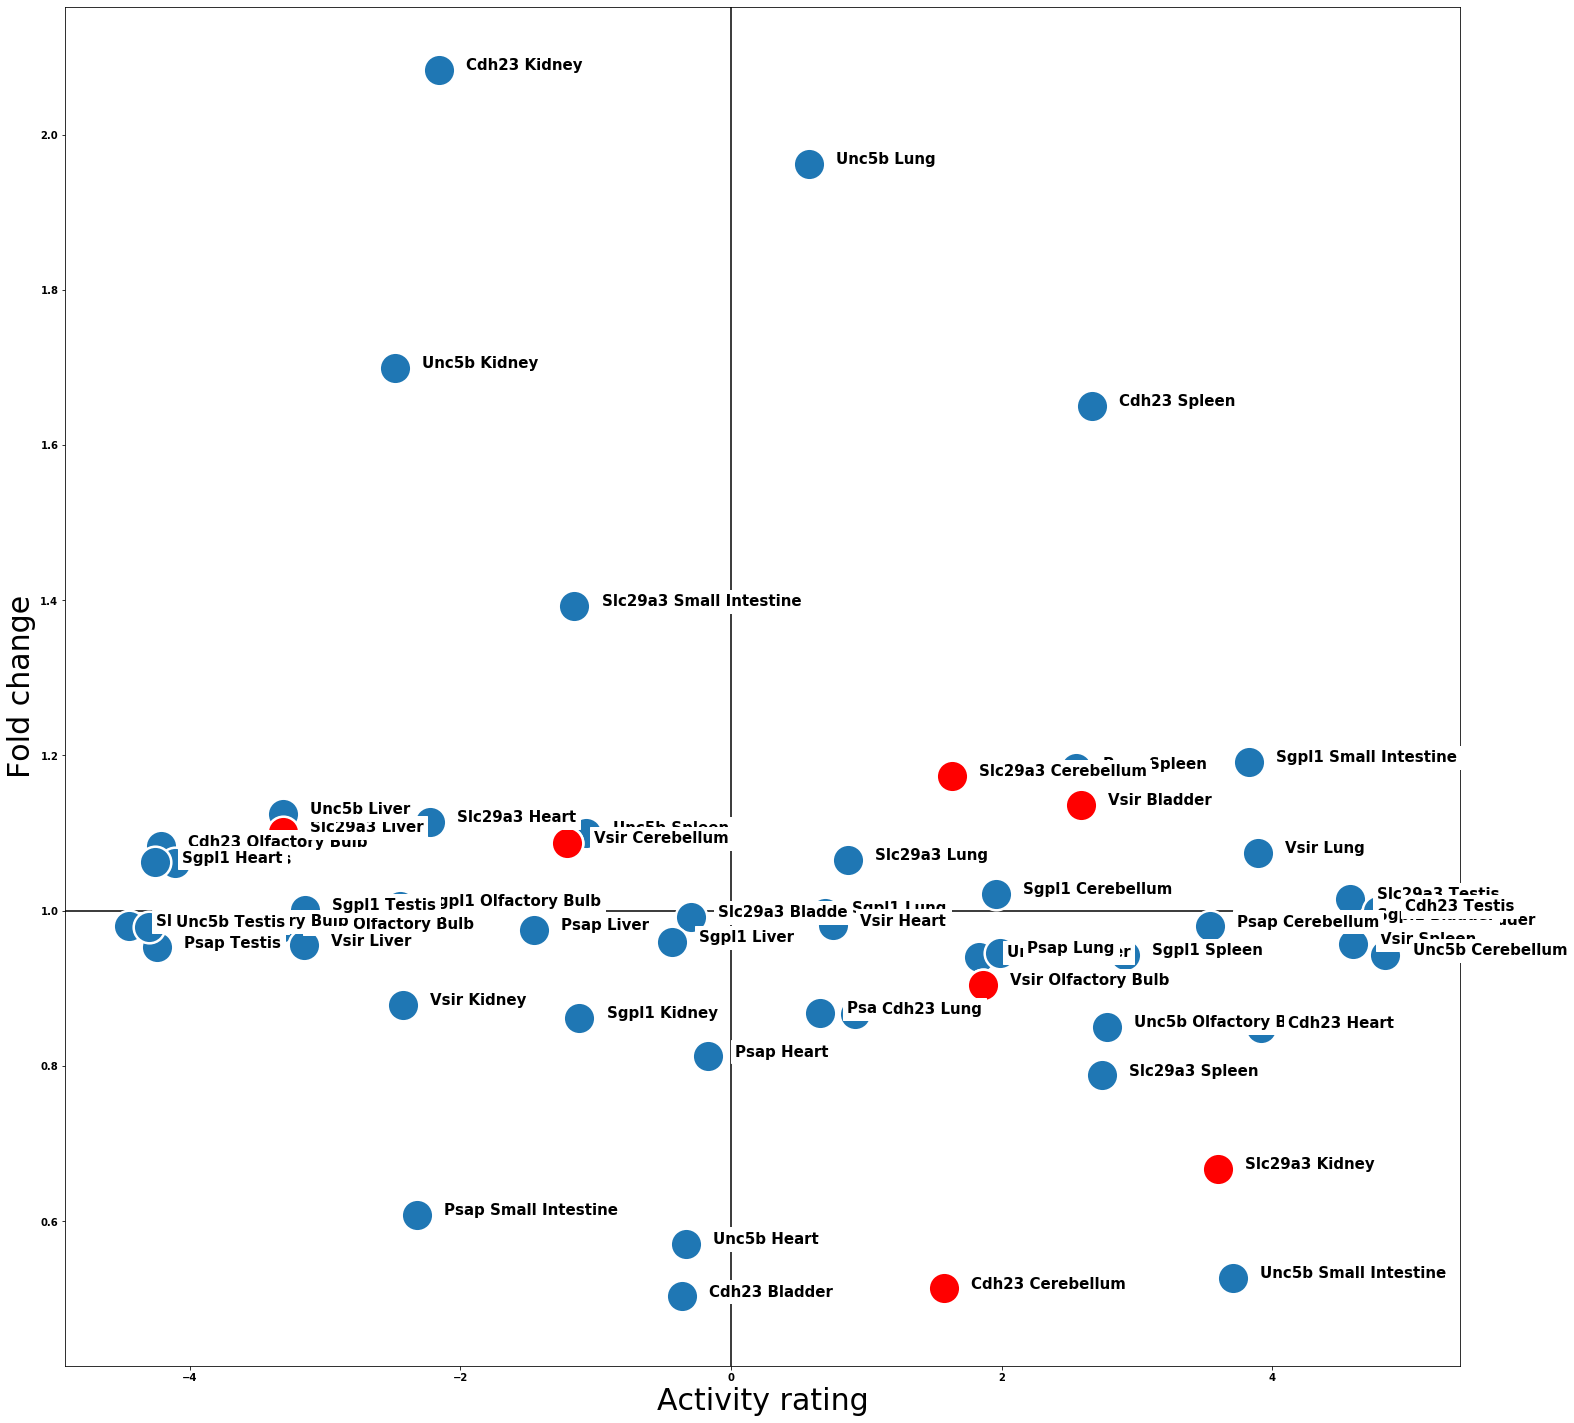

In [110]:
fig, ax = plt.subplots(figsize=(25,25))
#plt.xticks(rotation=90, ha='center')
ax.axhline(y=1, color='k', zorder = 0)
ax.axvline(x=0, color='k', zorder = 0)
plt.rcParams.update({'font.weight': 'bold','font.size': 10})
#ax.set(yticks=[-0.5, 1.5], xticks=[0, 1]) 
plot = sns.scatterplot(dfxyx['top'],dfxyx['fc'], s = 1000)
plot = sns.scatterplot(dfxyxpicked['top'],dfxyxpicked['fc'], s = 1000,color='red')
#ax.set_xlim([-5, 5])
#ax.set_ylim([0.45, 2.2])
#plot.legend_.remove()
#plot.set_yscale('log')
#plot.set_title('dfsdf')
plt.ylabel('Fold change', fontsize = 30)
plt.xlabel('Activity rating', fontsize = 30)
for line in range(0,dfxyx.shape[0]):
     plt.text(dfxyx.top[line]+0.2, dfxyx.fc[line], dfxyx.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

fig = plot.get_figure()
#fig.savefig("polcoord1.png")
#fig

C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


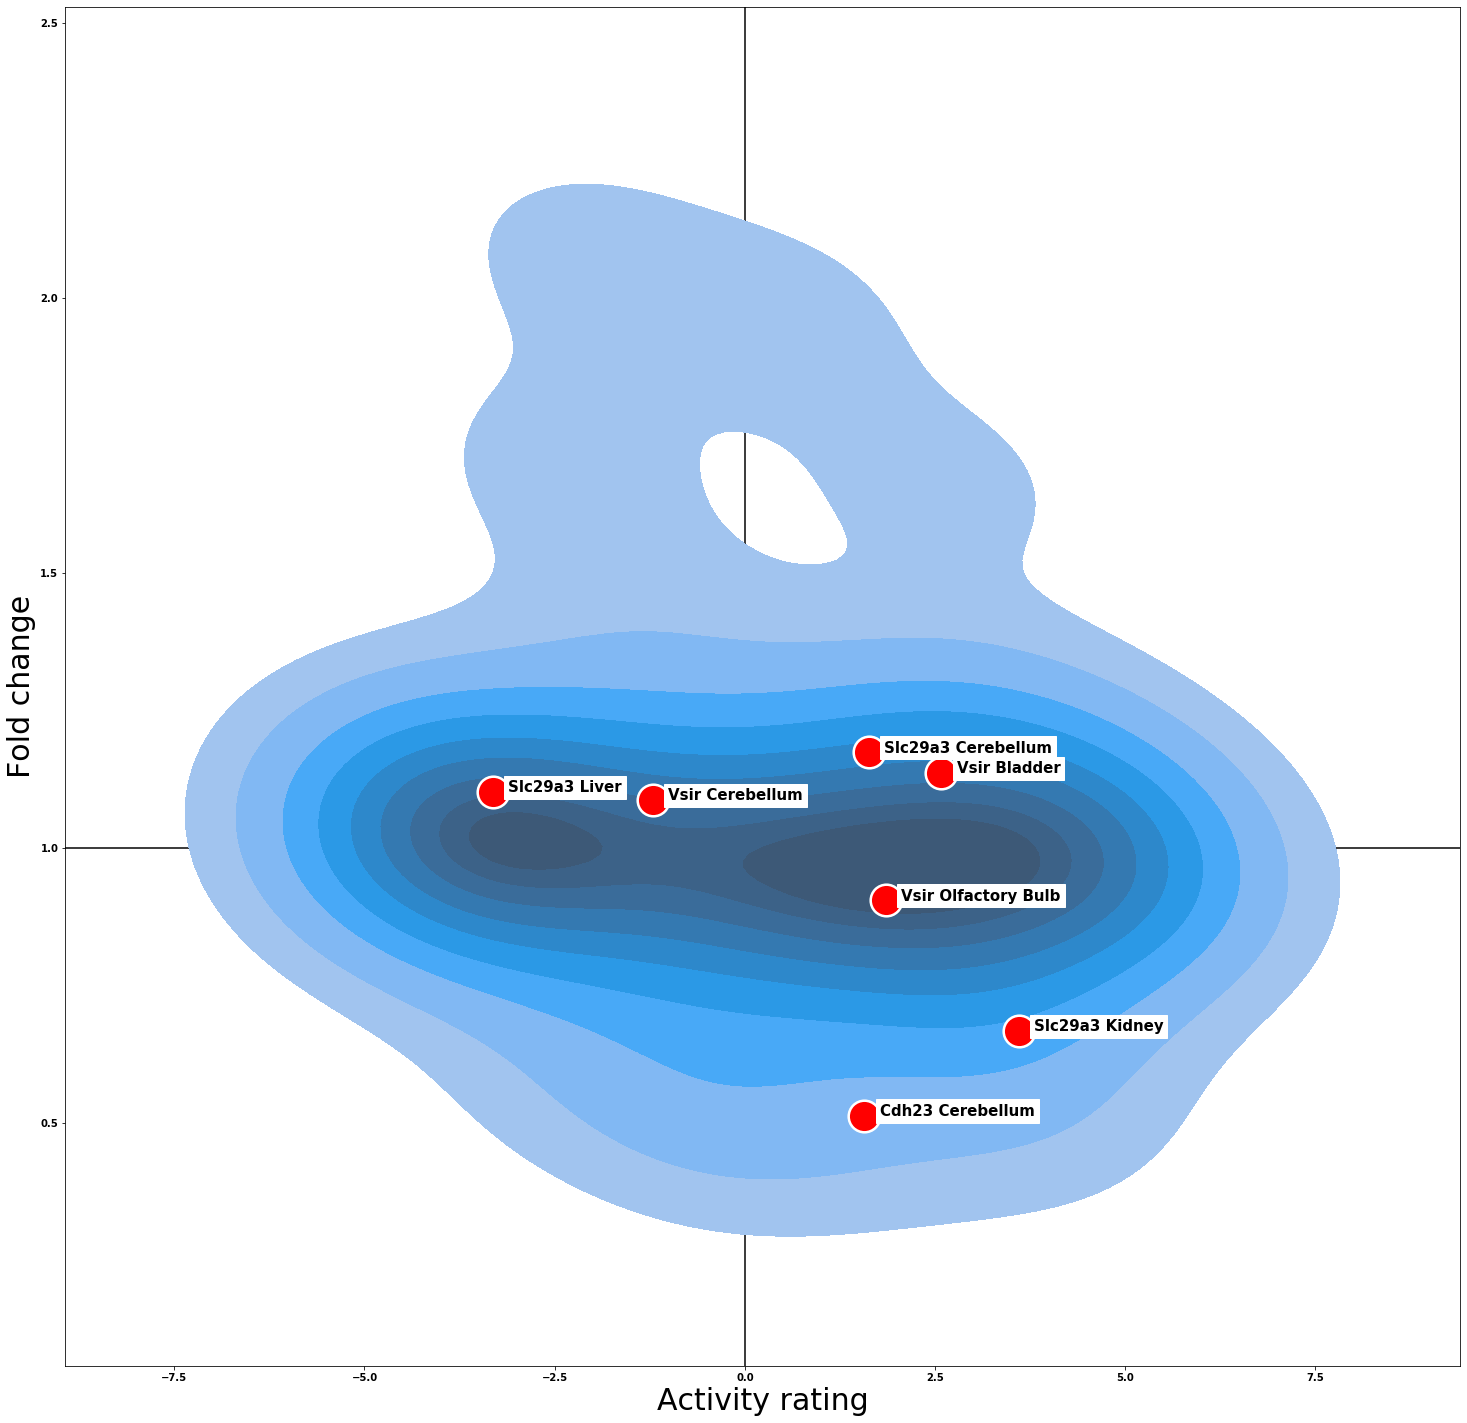

In [120]:
fig, ax = plt.subplots(figsize=(25,25))
#plt.xticks(rotation=90, ha='center')
ax.axhline(y=1, color='k', zorder = 0)
ax.axvline(x=0, color='k', zorder = 0)
plt.rcParams.update({'font.weight': 'bold','font.size': 10})
#ax.set(yticks=[-0.5, 1.5], xticks=[0, 1]) 
plot = sns.kdeplot(dfxyx['top'],dfxyx['fc'], fill=1)
plot = sns.scatterplot(dfxyxpicked['top'],dfxyxpicked['fc'], s = 1000,color='red')
#ax.set_xlim([-5, 5])
#ax.set_ylim([0.45, 2.2])
#plot.legend_.remove()
#plot.set_yscale('log')
#plot.set_title('dfsdf')
plt.ylabel('Fold change', fontsize = 30)
plt.xlabel('Activity rating', fontsize = 30)
for line in range(0,dfxyxpicked.shape[0]):
     plt.text(dfxyxpicked.top[line]+0.2, dfxyxpicked.fc[line], dfxyxpicked.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

fig = plot.get_figure()
fig.savefig("polcoord2.svg")

In [21]:
tmprt=pd.read_excel('TPM_RATE.xlsx', index_col=0)
dfxyx2=dfxyx.join(tmprt)
tmprt2=pd.read_excel('TPM_RATE_NORM.xlsx', index_col=0)
dfxyx2=dfxyx2.join(tmprt2)

In [22]:
dfxyx2
#= dfxyx

,fc,top,TPM,TPMN
Cdh23 Lung,0.867167,0.65976,0.370000,0.037627
Unc5b Lung,1.96268,0.593003,6.823333,0.289063
Slc29a3 Lung,1.06564,0.920981,5.273333,0.218659
Psap Lung,0.946062,1.83007,612.043333,0.549795
Vsir Lung,1.07432,3.73916,39.066667,0.630616
Sgpl1 Lung,0.99731,0.534001,18.966667,0.132727
Cdh23 Spleen,1.65081,2.58172,1.293333,0.131525
Unc5b Spleen,1.10003,-1.2273,1.853333,0.078514
Slc29a3 Spleen,0.787658,2.74015,14.800000,0.613683
Psap Spleen,1.18352,2.87678,785.320000,0.705449


C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


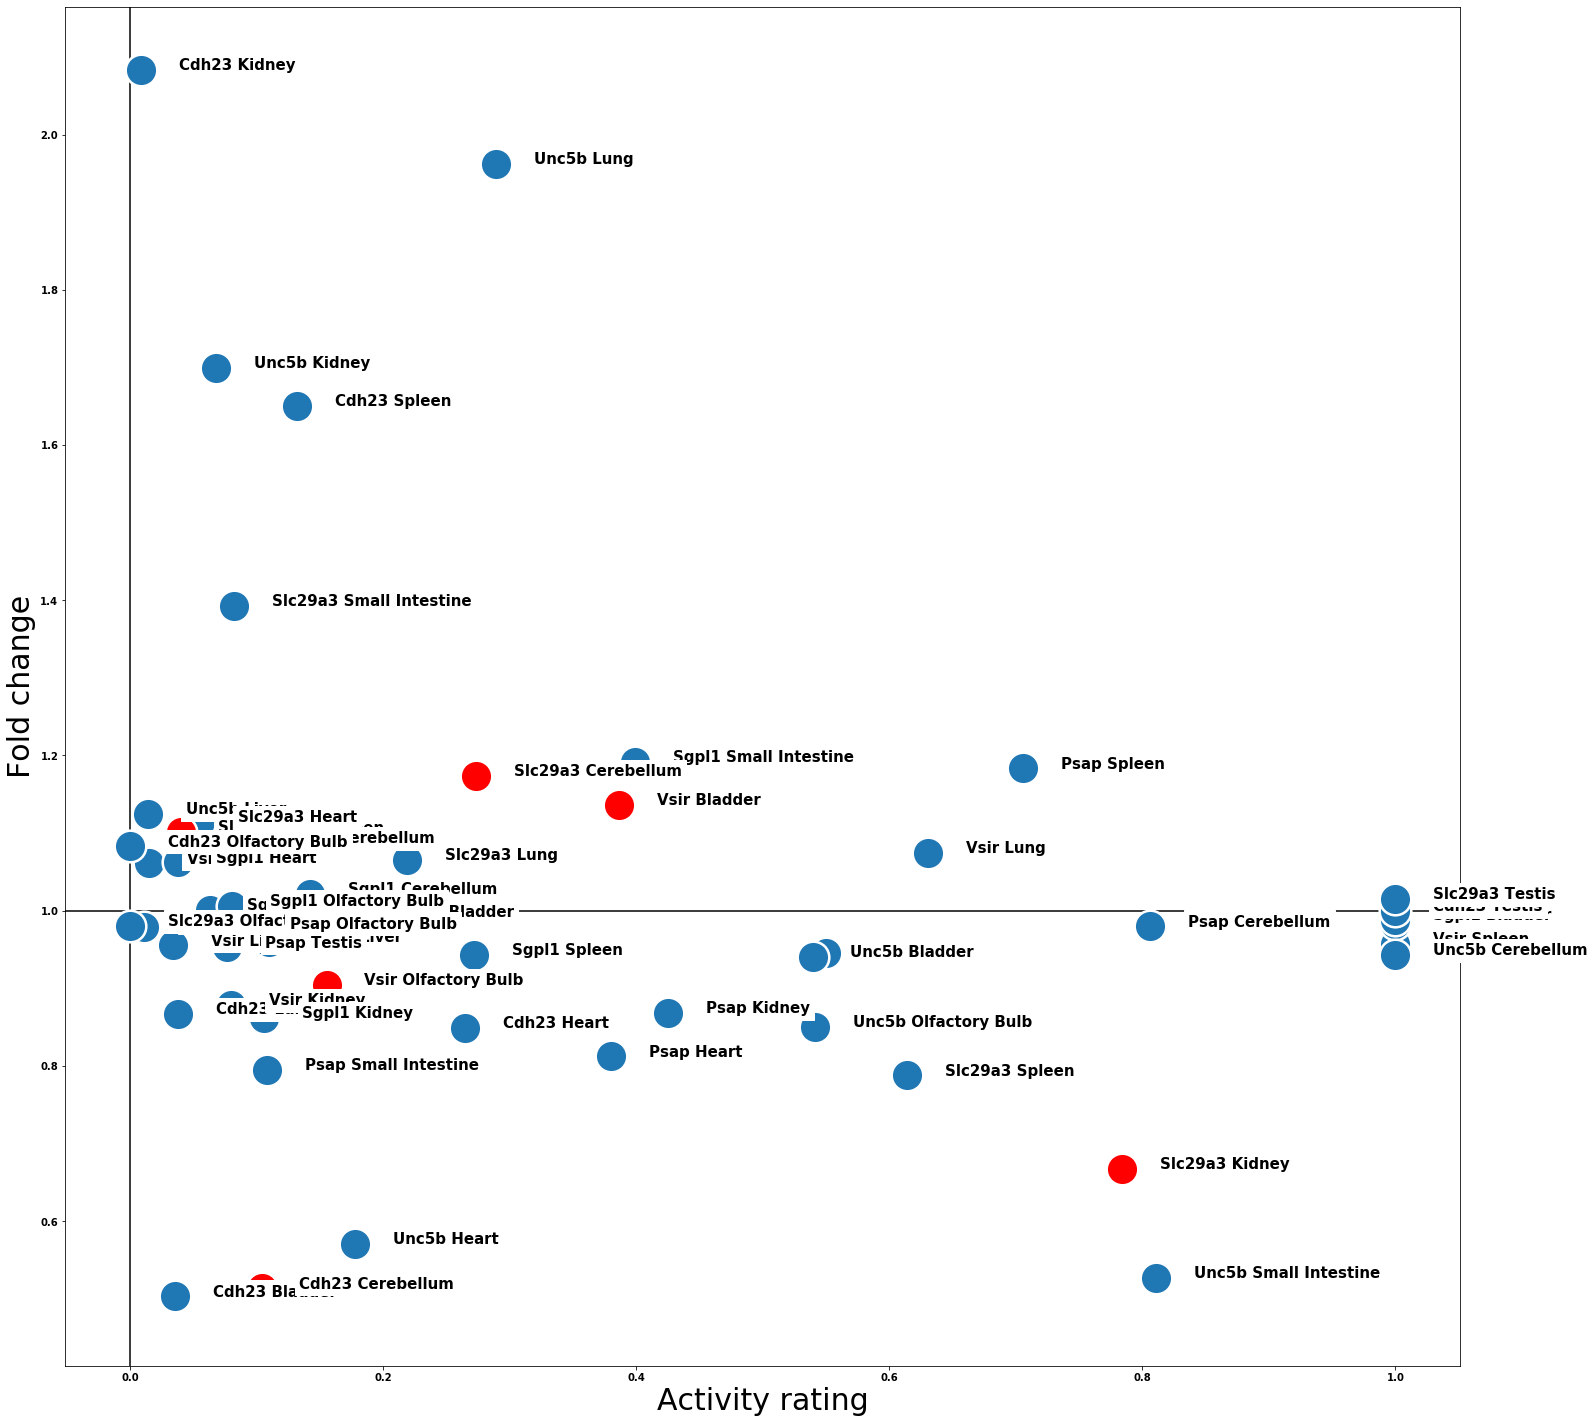

In [26]:
fig, ax = plt.subplots(figsize=(25,25))
#plt.xticks(rotation=90, ha='center')
ax.axhline(y=1, color='k', zorder = 0)
ax.axvline(x=0, color='k', zorder = 0)
plt.rcParams.update({'font.weight': 'bold','font.size': 10})
#ax.set(yticks=[-0.5, 1.5], xticks=[0, 1]) 
plot = sns.scatterplot(dfxyx2['TPMN'],dfxyx2['fc'], s = 1000)
plot = sns.scatterplot(dfxyxpicked['TPMN'],dfxyxpicked['fc'], s = 1000,color='red')
for line in range(0,dfxyx2.shape[0]):
     plt.text(dfxyx2.TPMN[line]+0.03, dfxyx2.fc[line], dfxyx2.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

#plot.set_xscale('log')
#ax.set_xlim([0, 20000])
#ax.set_ylim([0.45, 2.2])
#plot.legend_.remove()

#plot.set_yscale('log')
#plot.set_title('dfsdf')
plt.ylabel('Fold change', fontsize = 30)
plt.xlabel('Activity rating', fontsize = 30)
#for line in range(0,dfxyx.shape[0]):
#     plt.text(dfxyx.top[line]+0.2, dfxyx.fc[line], dfxyx.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

fig = plot.get_figure()

fig.savefig("polcoord8=.svg")

In [27]:
dfxyxpicked.to_csv('dfxyxpicked.csv')

In [28]:
dfxyx2.to_csv('dfxyx2.csv')

C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


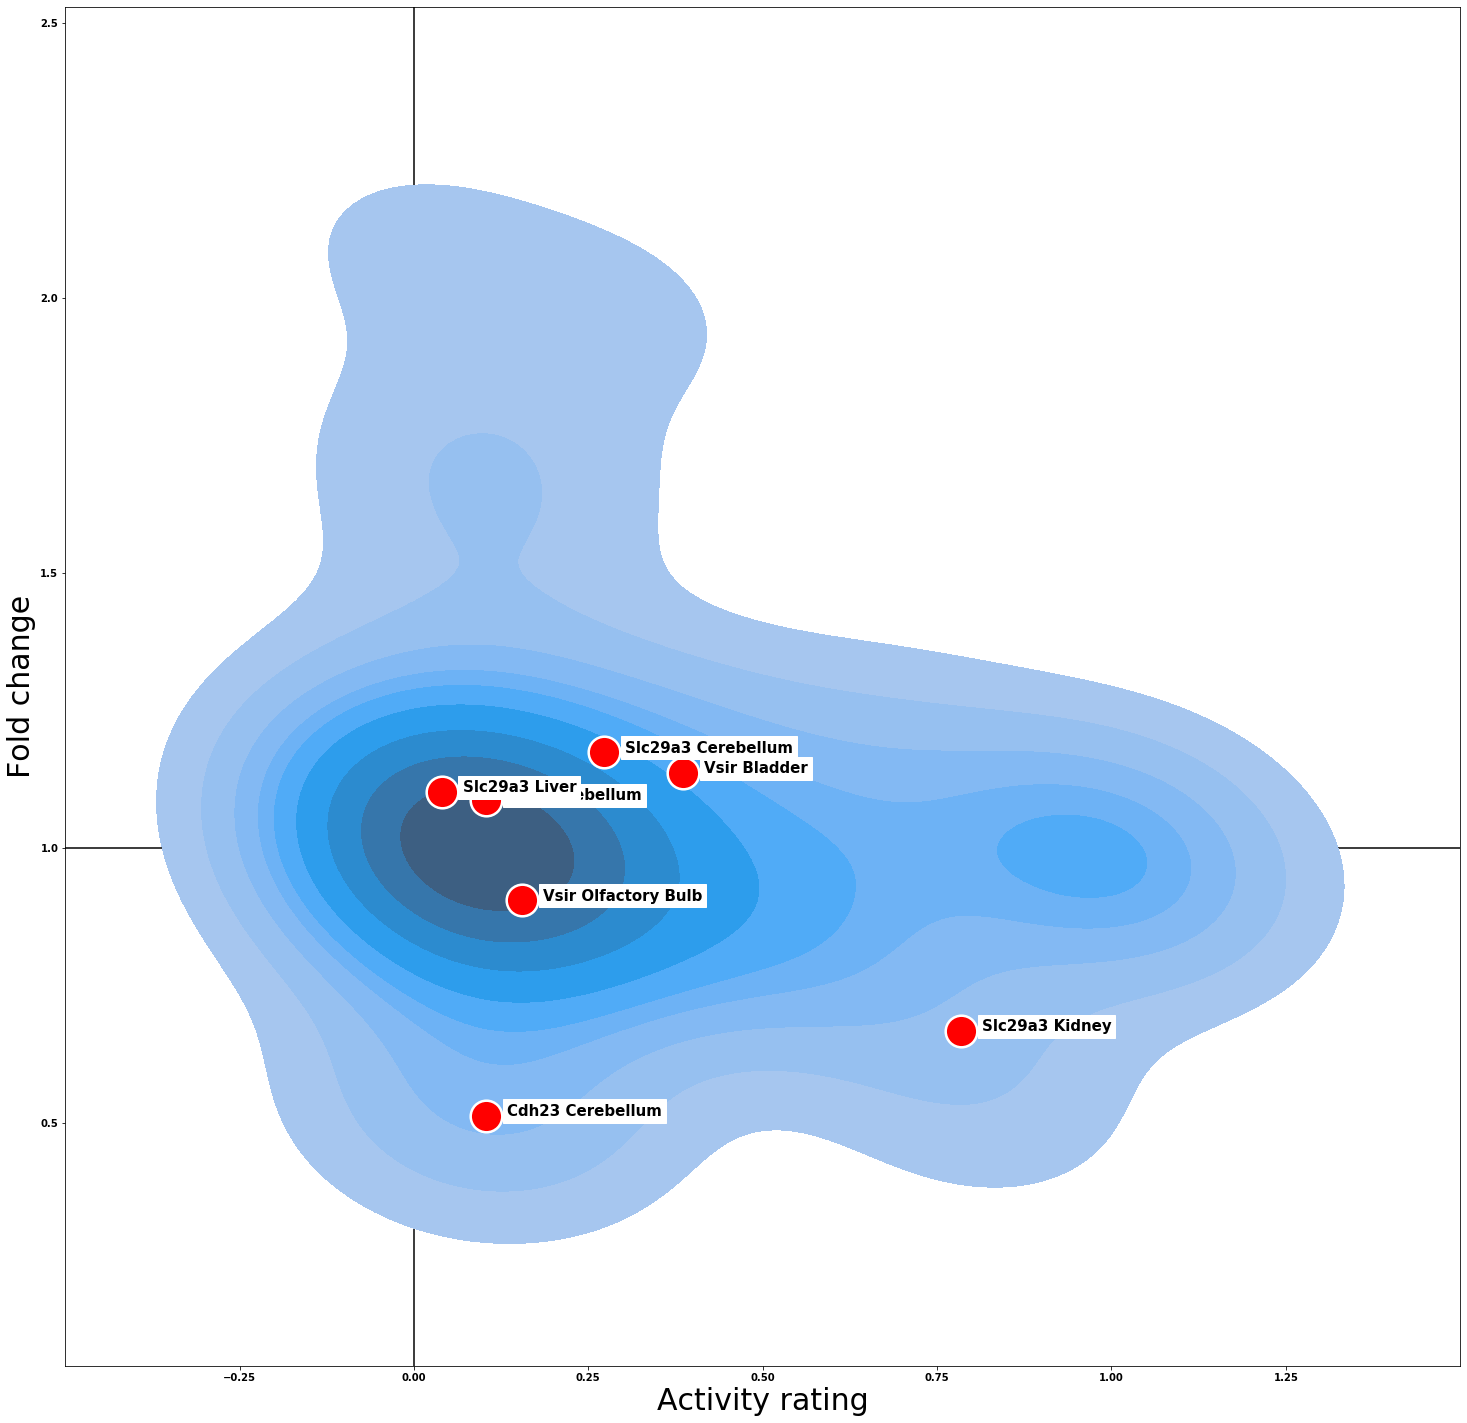

In [122]:
fig, ax = plt.subplots(figsize=(25,25))
#plt.xticks(rotation=90, ha='center')
ax.axhline(y=1, color='k', zorder = 0)
ax.axvline(x=0, color='k', zorder = 0)
plt.rcParams.update({'font.weight': 'bold','font.size': 10})
#ax.set(yticks=[-0.5, 1.5], xticks=[0, 1]) 
plot = sns.kdeplot(dfxyx2['TPMN'],dfxyx2['fc'], fill=1)
plot = sns.scatterplot(dfxyxpicked['TPMN'],dfxyxpicked['fc'], s = 1000,color='red')
for line in range(0,dfxyxpicked.shape[0]):
     plt.text(dfxyxpicked.TPMN[line]+0.03, dfxyxpicked.fc[line], dfxyxpicked.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

#ax.set_xlim([-5, 5])
#ax.set_ylim([0.45, 2.2])
#plot.legend_.remove()
#plot.set_yscale('log')
#plot.set_title('dfsdf')
plt.ylabel('Fold change', fontsize = 30)
plt.xlabel('Activity rating', fontsize = 30)
#for line in range(0,dfxyx.shape[0]):
#     plt.text(dfxyx.top[line]+0.2, dfxyx.fc[line], dfxyx.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

fig = plot.get_figure()
fig.savefig("polcoord4.svg")

C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


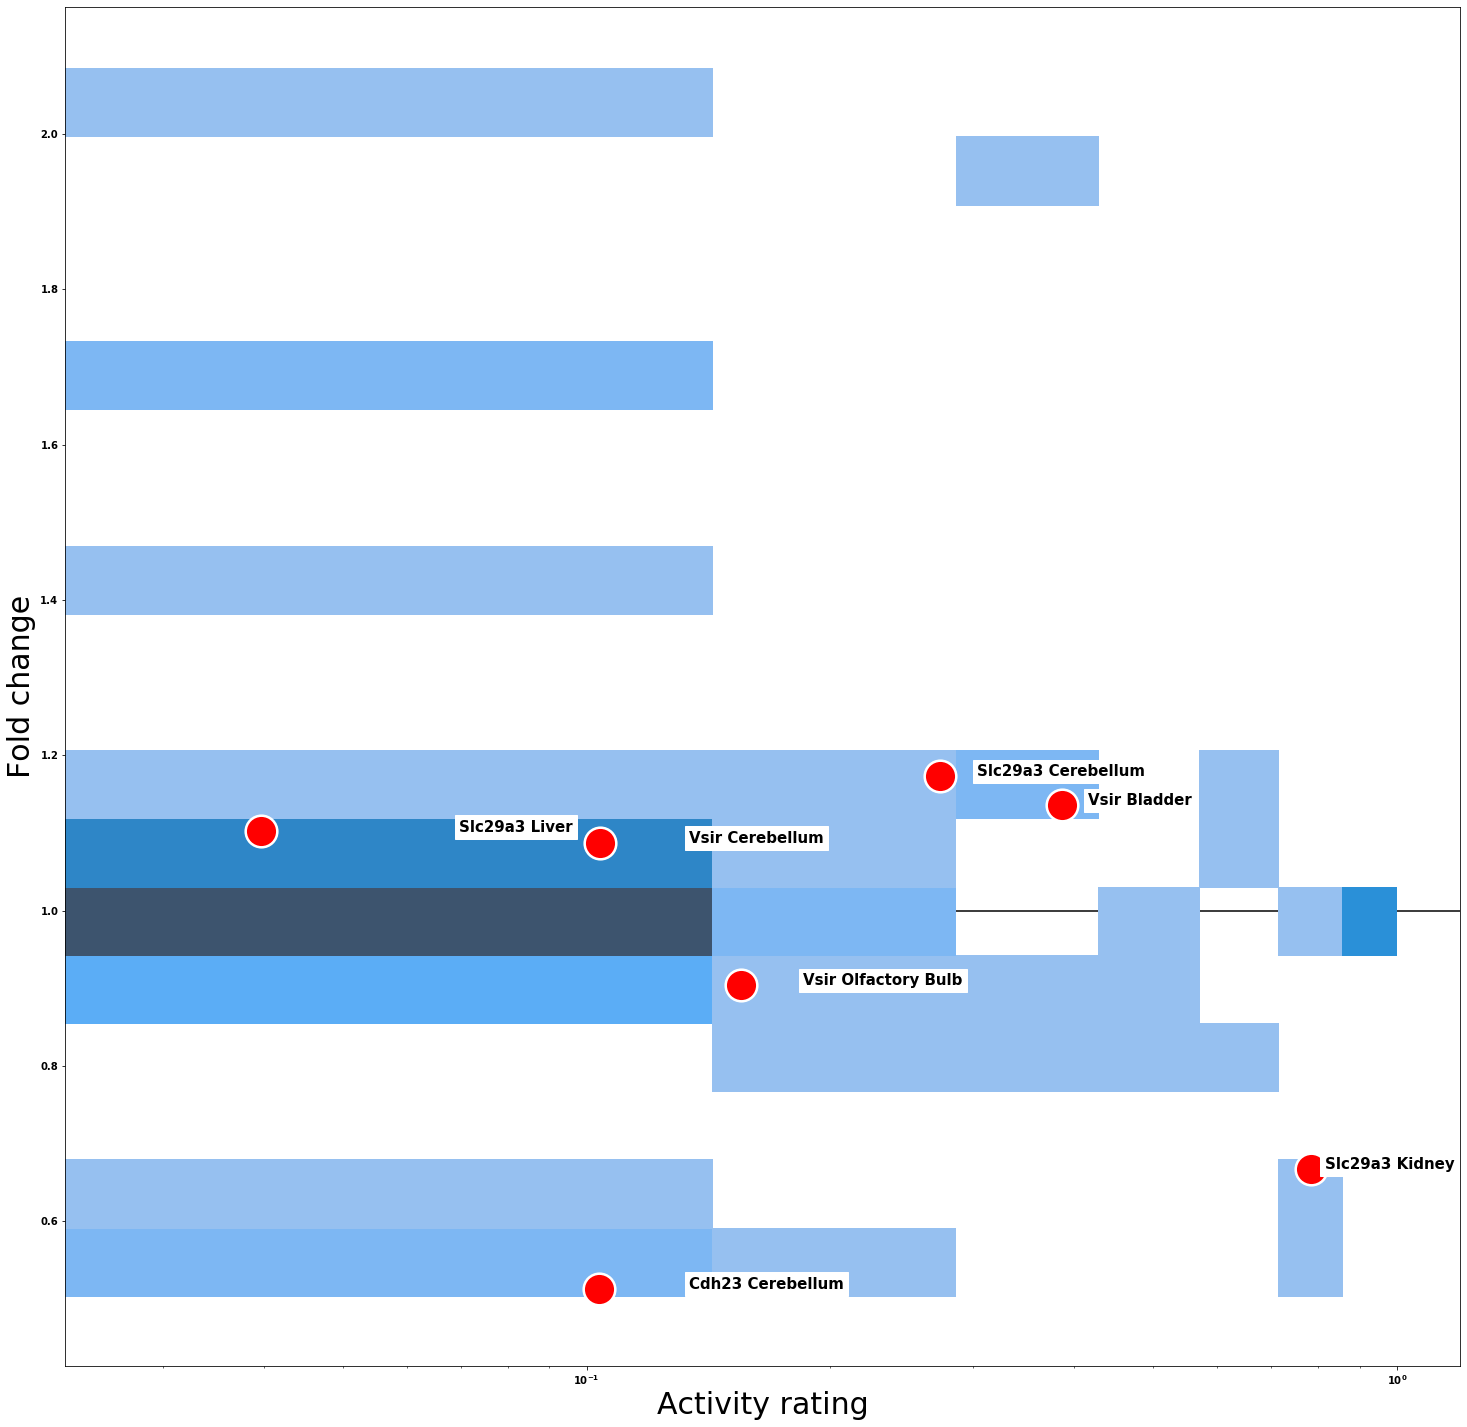

In [124]:
fig, ax = plt.subplots(figsize=(25,25))
#plt.xticks(rotation=90, ha='center')
ax.axhline(y=1, color='k', zorder = 0)
ax.axvline(x=0, color='k', zorder = 0)
plt.rcParams.update({'font.weight': 'bold','font.size': 10})
#ax.set(yticks=[-0.5, 1.5], xticks=[0, 1]) 
plot = sns.histplot(x=dfxyx2['TPMN'],y=dfxyx2['fc'])
#for line in range(0,dfxyx2.shape[0]):
#     plt.text(dfxyx2.TPMN[line]+0.01, dfxyx2.fc[line], dfxyx.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')
plot = sns.scatterplot(dfxyxpicked['TPMN'],dfxyxpicked['fc'], s = 1000,color='red')
for line in range(0,dfxyxpicked.shape[0]):
     plt.text(dfxyxpicked.TPMN[line]+0.03, dfxyxpicked.fc[line], dfxyxpicked.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

        #ax.set_xlim([-5, 5])
#ax.set_ylim([0.45, 2.2])
#plot.legend_.remove()
plot.set_xscale('log')
#plot.set_title('dfsdf')
plt.ylabel('Fold change', fontsize = 30)
plt.xlabel('Activity rating', fontsize = 30)
#for line in range(0,dfxyx.shape[0]):
#     plt.text(dfxyx.top[line]+0.2, dfxyx.fc[line], dfxyx.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

#fig = plot.get_figure()
fig.savefig("polcoord6.svg")

C:\Users\1289746\Anaconda3\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


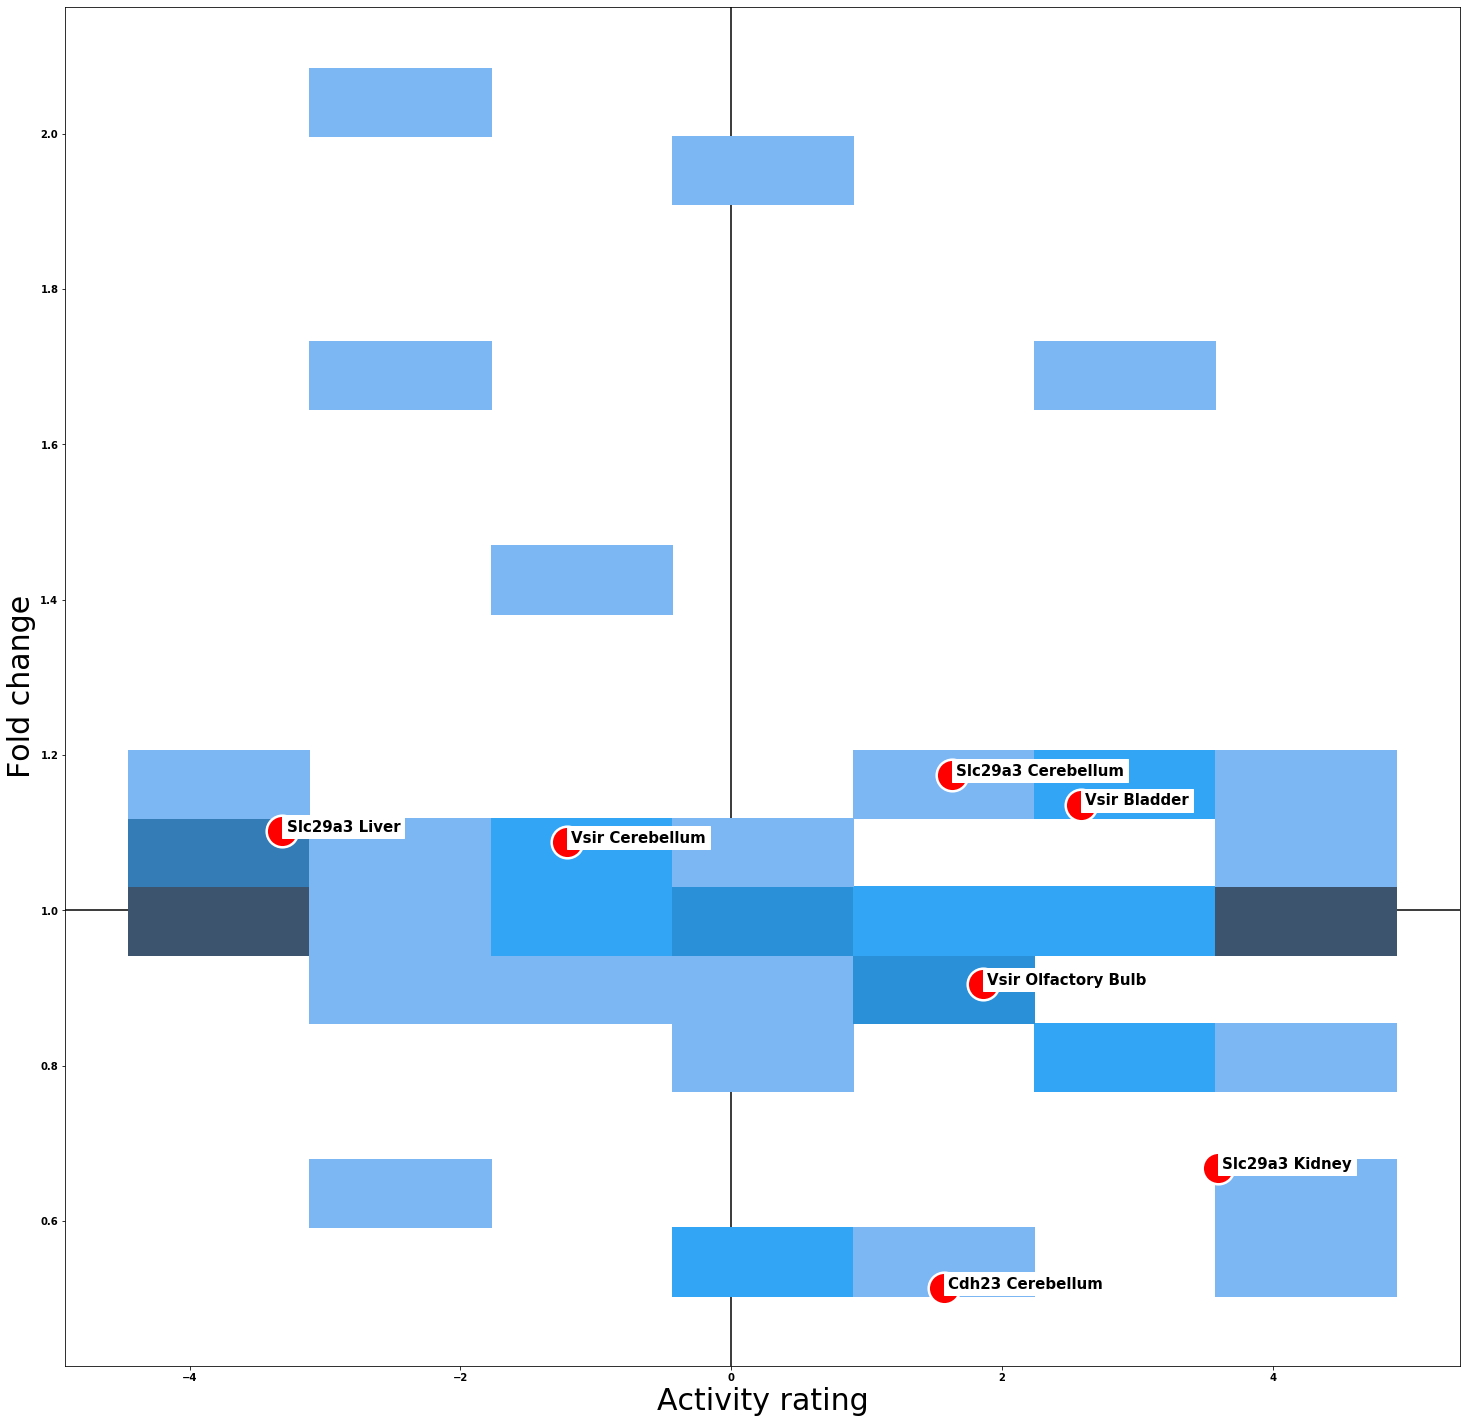

In [123]:
fig, ax = plt.subplots(figsize=(25,25))
#plt.xticks(rotation=90, ha='center')
ax.axhline(y=1, color='k', zorder = 0)
ax.axvline(x=0, color='k', zorder = 0)
plt.rcParams.update({'font.weight': 'bold','font.size': 10})
#ax.set(yticks=[-0.5, 1.5], xticks=[0, 1]) 
plot = sns.histplot(x=dfxyx2['top'],y=dfxyx2['fc'])
#for line in range(0,dfxyx2.shape[0]):
#     plt.text(dfxyx2.TPMN[line]+0.01, dfxyx2.fc[line], dfxyx.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')
plot = sns.scatterplot(dfxyxpicked['top'],dfxyxpicked['fc'], s = 1000,color='red')
for line in range(0,dfxyxpicked.shape[0]):
     plt.text(dfxyxpicked.top[line]+0.03, dfxyxpicked.fc[line], dfxyxpicked.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

        #ax.set_xlim([-5, 5])
#ax.set_ylim([0.45, 2.2])
#plot.legend_.remove()
#plot.set_yscale('log')
#plot.set_title('dfsdf')
plt.ylabel('Fold change', fontsize = 30)
plt.xlabel('Activity rating', fontsize = 30)
#for line in range(0,dfxyx.shape[0]):
#     plt.text(dfxyx.top[line]+0.2, dfxyx.fc[line], dfxyx.index[line], horizontalalignment='left', size=15, color='black', weight='semibold', backgroundcolor = 'w')

#fig = plot.get_figure()
fig.savefig("polcoord5.svg")

In [53]:
l = 'psap si_psapvsir2-analysis.csv'
wt=l+' wt'
snp=l+' snp'
f = bdf2.loc[:,[wt,snp]].replace(0.0, np.nan).dropna()
print(f)
wtl = []
dell = [] 
wtl1 = []
dell1 = []
for i,row in f.iterrows():
    if i.__contains__("epb"):
        wtl.append(row[wt]/row[snp])
    if i.__contains__("unc"):
        dell.append(row[wt]/row[snp])
        
            
zscc1 = list(stats.zscore(wtl))

for i in zscc1:
    if abs(i) < 3:
        wtl1.append(wtl[list(zscc1).index(i)])    
zsce1 = list(stats.zscore(dell))
for i in zsce1:
    if abs(i) < 3:
        dell1.append(dell[list(zsce1).index(i)])
print(wtl,zscc1,dell,zsce1)

       psap si_psapvsir2-analysis.csv wt  psap si_psapvsir2-analysis.csv snp
unc03                             0.3895                              0.1885
unc04                             1.0320                              0.4270
unc02                             0.1875                              0.3860
unc06                             0.3765                              0.9395
epb06                             0.5730                              0.5730
epb03                             0.7440                              0.3875
epb02                             2.5000                              2.1000
unc05                             0.3810                              1.1265
epb01                             5.6000                              1.6500
[1.0, 1.92, 1.1904761904761905, 3.3939393939393936] [-0.9308417035222006, 0.046638674146235355, -0.728464813735775, 1.61266784311174] [2.06631299734748, 2.4168618266978923, 0.48575129533678757, 0.4007450771687068, 0.33821571238348

In [30]:
def graph1(file, organ, gene, ax, delete_outliers = True, ztresh = 2, trait = "RE", errors = "CISUM", title = "GRAPH", y = 'y'):
    
    #plt.style.use('fivethirtyeight')
    #plt.style.use('seaborn-whitegrid')
    csfont = {'fontname':'Arial', 'fontsize':14}
    plt.rcParams['axes.facecolor'] = 'white'
    plt.figure(figsize = [10, 10])
    
    s = 60
    edgecolors='#000000'
    alpha = 0.7
    ex_c = 'red'
    ct_c = 'blue'
    
    
    # divide data to mouse groups, cut organ/gene info, take means
    ct = file[file.Group == 'ctr']  
    ex = file[file.Group == 'exp']
    ct = ct[ct.Organ == organ]
    ex = ex[ex.Organ == organ]
    ct = ct[ct.Gene == gene]
    ex = ex[ex.Gene == gene]
    ct = ct.groupby("Mouse").mean().reset_index()
    ex = ex.groupby("Mouse").mean().reset_index()

    #create two bars with sem 
        
    ax.bar(0.1, ct[trait].mean(), color = 'white', edgecolor='black',width=0.5, alpha = 1, zorder=-1)
    ax.errorbar(0.1, ct[trait].mean(), (ct[trait].sem()), c = '#000000', capsize=9)

    #plt.errorbar(0.1, ct[trait].mean(), xerr = 0.1, c = '#000000')
    
    ax.bar(0.8, ex[trait].mean(), color = 'white', edgecolor='black',width=0.5, alpha = 1, zorder=-1)
    ax.errorbar(0.8, ex[trait].mean(), (ex[trait].sem()), c = '#000000', capsize=9)
    #plt.errorbar(0.8, ex[trait].mean(), xerr = 0.1, c = '#000000')
        

        

    #create two csatters and two lists for stats
    ctrlist1 = []
    explist1 = []
    ctrlcoords = []
    expcoords = []
    
    for i in (list(ct['Mouse'])):
        x =(-0.15+(0.45/len(list(ct['Mouse'])))*(list(ct['Mouse']).index(i) + 1))
        y =(ct.loc[ct['Mouse']==i][trait])
        if pd.isna(float(y)) == False:
            ctrlist1.append(float(y))
            ctrlcoords.append(x)
            ax.scatter(x, y,s=s,edgecolors=edgecolors, c = ct_c, alpha = 0.7)    
            ax.errorbar(x, y, xerr=0, yerr= y*(ct.loc[ct['Mouse']==i][errors])/400,c = ct_c, alpha = 0.7) # 38% CI
            ax.annotate(i,(x+0.01,y+0.01))
    
    for i in (list(ex['Mouse'])):
        x =(0.55+(0.45/len(list(ex['Mouse'])))*(list(ex['Mouse']).index(i) + 1))
        y =(ex.loc[ex['Mouse']==i][trait])
        if pd.isna(float(y)) == False:
            explist1.append(float(y))
            expcoords.append(x)
            ax.scatter(x, y,s=s,edgecolors=edgecolors, c = ex_c, alpha = 0.7)    
            ax.errorbar(x, y, xerr=0, yerr= y*(ex.loc[ex['Mouse']==i][errors])/400,c = ex_c, alpha = 0.7) 
            ax.annotate(i,(x+0.01,y+0.01))
    #print(explist1, ctrlist1)
    
    
        #delete outliars module     
    ctrlist =[]
    explist =[]
    if delete_outliers == True:
        zscc1 = list(stats.zscore(ctrlist1))
        #print(zscc1)
        for i in zscc1:
            #print(i)
            #print(list(zscc1).index(i))
            if abs(i) < ztresh:
                ctrlist.append(ctrlist1[list(zscc1).index(i)])
            else:
                ax.scatter(ctrlcoords[zscc1.index(i)], ctrlist1[zscc1.index(i)], s=300, marker="x", c="k")
         
        zsce1 = list(stats.zscore(explist1))
        #print(zsce1) 
        for i in zsce1:
            #print(i)
            #print(list(zsce1).index(i))
            if abs(i) < ztresh:
                explist.append(explist1[list(zsce1).index(i)])
            else:
                ax.scatter(expcoords[zsce1.index(i)], explist1[zsce1.index(i)], s=300, marker="x", c="k")      
    else:
        ctrlist = ctrlist1
        explist = explist1    
    
    if len(explist) < 3 or len(ctrlist) < 3:
        return(print('this is ploho'))
    shctr = str(round(stats.shapiro(ctrlist)[0],5))
    shexp = str(round(stats.shapiro(explist)[0],5))
    ttest = str(round(stats.ttest_ind(ctrlist, explist)[1],5))
    utest = str(round(stats.mannwhitneyu(ctrlist, explist)[1],5))

    
    if float(ttest) < 0.05 or float(utest) <0.05:    
        c="r"
        fs = 10
    else:
        c="k"
        fs=10
    
    #ax.set_yticks(**csfont)
    ax.set_ylabel("Relative expression")
    ax.set_title(title)    
    
    ax.set_xticks([0.1,0.35,0.8])
    ax.set_xticklabels([f"control \n shapiro = {shctr}",
                                f"u = {utest} \n t = {ttest}",
                                f"experiment \n shapiro = {shexp}"], color=c, fontsize=fs)
    ax.set_title(organ + " " + gene)
    
    
    #plt.text(0.75,-0.4, s=)
    #plt.text(0,-1, s="shapiro = "+shctr)
    #plt.text(0.7,-1, s="shapiro = "+shexp)
    #plt.text(0.4,-1, s="u = "+ utest + "\n" "t = "+ ttest)
    

    #plt.xticks(d, ('Контроль Slc29a3', 'UNCdM1R1 Slc29a3', 'Контроль Unc5b','UNCdM1R1 Unc5b'),**csfont, rotation=70)


    #plt.savefig(f"pics/{organ} bl {gene} bl {title}.jpg", transparent=True, bbox_inches="tight", dpi = 200)
    
    
    #plt.show()
    return(ax)

0.8464644978473196
ob psap ctr
ob psap exp
1.3283608121350556
ob sgpl ctr
ob sgpl exp
0.9316426037492544
liv psap ctr
liv psap exp
1.1843852601262674
liv sgpl ctr
liv sgpl exp
0.9646984833773058
spl psap ctr
spl psap exp
1.1134548795192674
spl sgpl ctr
spl sgpl exp
0.9793523609945993
bd psap ctr
bd psap exp
1.0339234320225619
bd sgpl ctr
bd sgpl exp


In [ ]:
for o in set(df1["Organ"]):
    if o != 'ntc':
        a1 = df1[df1.Organ == o]
        for g in set(a1["Gene"]):
            if g != 'ntc':
                for group in ["ctr", "exp"]:
                    norm(df1, o, group, g)


In [15]:
df = parse(filelist[0])
df=0

In [ ]:
        zscc1 = list(stats.zscore(wtl))
        for i in zscc1:
            if abs(i) < ztresh:
                wtl1.append(wtl[list(zscc1).index(i)])
         
        zsce1 = list(stats.zscore(dell))
        for i in zsce1:
            if abs(i) < ztresh:
                dell1.append(dell[list(zsce1).index(i)])